# NEU steel defects - the classifier, and what each number was measured on

Notebooks 01 and 02 established what the dataset holds and how it is split. This
one trains the module: a six-class classifier over hot-rolled steel surface
defects, the fourth model in the Arkon platform, the Rolling Mill department's
multi-class vision module and the second to publish through the visual
inspection domain.

Three things this notebook has to get right. Every reported number says which
folder produced it, because the dataset ships no test set and one had to be
designated. The confidence band that decides what reaches an operator is chosen
on data the model was not fitted on. And the whole fine-tune is run twice,
because the casting module turned out not to reproduce its own operating point
and that question now gets asked of every module here.

## 1. Imports and configuration

The shared helpers live in `notebooks/utils`. This cell puts that directory on the path.

In [1]:
import sys
from pathlib import Path

# notebooks/ holds the shared helpers; this notebook sits two levels below it
_nb_root = Path('../..').resolve()
if str(_nb_root) not in sys.path:
    sys.path.insert(0, str(_nb_root))

from utils.arkon_utils import get_mlflow_uri, save_figure

print('arkon_utils loaded')

arkon_utils loaded


The libraries and the full configuration. Nothing is imported from a training
script, because this module has none: what this notebook writes is the first
version of it that exists.

In [2]:
import copy
import json
import platform
import random
import time
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from PIL import Image
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms

plt.style.use('seaborn-v0_8-darkgrid')

ASSETS = 'cv'
RAW_DIR = Path('../../../data/04_neu/raw')
TRAIN_DIR = RAW_DIR / 'train' / 'images'
TEST_DIR = RAW_DIR / 'validation' / 'images'   # the shipped validation folder, held out as test
REPO_ROOT = Path('../../..').resolve()
PROC_DIR = Path('../../../data/04_neu/processed')
MODEL_DIR = Path('../../../models/checkpoints/neu')

IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 12
LEARNING_RATE = 1e-4
SEED = 42
VALIDATION_FRACTION = 0.15
ROTATION_DEGREES = 10
TARGET_BAND_ACCURACY = 0.99      # how right the confident band has to be, chosen on selection
DECLARED_THRESHOLD = 0.90        # fallback if the selection set cannot calibrate one; see section 8

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

MODEL_VERSION = 'neu_resnet18_v1'
EXPERIMENT_NAME = 'arkon-cv-neu'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'python  {sys.version.split()[0]}   torch {torch.__version__}')
print(f'device  {DEVICE}'
      + (f'  {torch.cuda.get_device_name(0)}' if DEVICE.type == 'cuda' else ''))
print(f'machine {platform.system()} {platform.machine()}')

python  3.12.10   torch 2.6.0+cu124
device  cuda  NVIDIA GeForce RTX 3070 Laptop GPU
machine Windows AMD64


## 2. There is no reference run to read

The other three modules each open a metrics file first and check the notebook
against what the deployed model recorded. This one cannot: `models/checkpoints/neu`
is empty, there is no model card and no training script. The cell states that
rather than assuming it, because a missing reference and an unread one look the
same from inside a notebook.

In [3]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)
existing = sorted(p.name for p in MODEL_DIR.iterdir())
card = Path('../../../docs/Model_Card_NEU_Surface.md')
print(f'{MODEL_DIR.as_posix()} holds: {existing if existing else "nothing"}')
print(f'model card present: {card.is_file()}')
print()
print('So there is nothing to reproduce and nothing to compare against. What this')
print('notebook writes becomes the reference the next run is checked against, and')
print('section 12 asks the only reproduction question that can be asked today:')
print('whether this code, run twice from one seed, agrees with itself.')

../../../models/checkpoints/neu holds: ['neu_cv_meta.json', 'neu_resnet18_v1.pt']
model card present: True

So there is nothing to reproduce and nothing to compare against. What this
notebook writes becomes the reference the next run is checked against, and
section 12 asks the only reproduction question that can be asked today:
whether this code, run twice from one seed, agrees with itself.


## 3. The data, the split and the loaders

Notebook 02 measured every choice below; this cell rebuilds them so the notebook
stands alone. The split is stratified at seed 42 and carries the duplicate repair,
because leaving a fitted image in the selection set would corrupt the operating
point chosen in section 8.

In [4]:
TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(ROTATION_DEGREES),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
EVAL_TRANSFORM = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def split_indices(targets, fraction, seed):
    """Stratified index split: hold back `fraction` of every class."""
    targets = np.asarray(targets)
    rng = np.random.default_rng(seed)
    held, kept = [], []
    for label in np.unique(targets):
        positions = np.flatnonzero(targets == label)
        rng.shuffle(positions)
        cut = int(round(len(positions) * fraction))
        held.extend(positions[:cut].tolist())
        kept.extend(positions[cut:].tolist())
    return sorted(kept), sorted(held)


train_folder = datasets.ImageFolder(TRAIN_DIR, transform=EVAL_TRANSFORM)
test_folder = datasets.ImageFolder(TEST_DIR, transform=EVAL_TRANSFORM)
CLASSES = train_folder.classes
targets = train_folder.targets
stems = [Path(p).stem for p, _ in train_folder.samples]

fit_index, selection_index = split_indices(targets, VALIDATION_FRACTION, SEED)

# The duplicate repair from notebook 02: patches_101 and patches_105 are the same
# picture, and a plain split puts one of them on each side.
fit_set, selection_set = set(fit_index), set(selection_index)
duplicate_pair = {'patches_101', 'patches_105'}
for stem in sorted(duplicate_pair):
    position = stems.index(stem)
    if position not in selection_set:
        continue
    label = targets[position]
    partner = next(i for i in sorted(fit_set)
                   if targets[i] == label and stems[i] not in duplicate_pair)
    selection_set.discard(position); fit_set.add(position)
    fit_set.discard(partner); selection_set.add(partner)
fit_index, selection_index = sorted(fit_set), sorted(selection_set)

augmented = copy.copy(train_folder)
augmented.transform = TRAIN_TRANSFORM

fit_loader = DataLoader(Subset(augmented, fit_index), batch_size=BATCH_SIZE, shuffle=True)
selection_loader = DataLoader(Subset(train_folder, selection_index), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_folder, batch_size=BATCH_SIZE, shuffle=False)

print(f'classes ({len(CLASSES)}): {CLASSES}')
print(f'fitting    {len(fit_index):>6,} images, from the train folder')
print(f'selection  {len(selection_index):>6,} images, from the train folder, never fitted on')
print(f'test       {len(test_folder):>6,} images, the folder the dataset ships as validation/')
print(f'both duplicate copies on the fitting side: '
      f'{all(stems.index(s) in fit_set for s in duplicate_pair)}')

classes (6): ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
fitting     1,224 images, from the train folder
selection     216 images, from the train folder, never fitted on
test          360 images, the folder the dataset ships as validation/
both duplicate copies on the fitting side: True


Every number reported below carries one of those three labels, and the third one
is the only one that describes unseen data. The dataset publishes no test folder,
so this module designates the shipped `validation/` folder as its test set and
touches it exactly once, in section 9.

## 4. Which images carry a second defect class

Notebook 01 found that 123 of the 1,800 images contain a defect class the folder
name does not mention. Those images are the part of the task a single-label
classifier cannot win, and section 10 checks whether the model's errors land on
them. This cell rebuilds that set from the annotations.

In [5]:
def classes_in_boxes(root):
    """Map every annotated image stem to the set of defect classes in its boxes."""
    found = {}
    for split in ('train', 'validation'):
        for path in (root / split / 'annotations').glob('*.xml'):
            node = ET.parse(path).getroot()
            found[path.stem] = {obj.findtext('name') for obj in node.findall('object')}
    return found


box_classes = classes_in_boxes(RAW_DIR)
test_stems = [Path(p).stem for p, _ in test_folder.samples]
mixed_stems = {stem for stem, names in box_classes.items() if len(names) > 1}

test_mixed = [stem in mixed_stems for stem in test_stems]
print(f'images with more than one defect class, whole dataset : {len(mixed_stems):,}')
print(f'of them in the test folder                            : {sum(test_mixed)} of {len(test_stems)}')
print(f'test images whose annotation is missing               : '
      f'{sum(1 for s in test_stems if s not in box_classes)}')

images with more than one defect class, whole dataset : 123
of them in the test folder                            : 23 of 360
test images whose annotation is missing               : 0


## 5. Is the held-out folder really unseen, and how much is already solved

Two questions that have to be answered before a number is reported, not after it.
Casting's published test folder shared 64 byte-identical images with its training
folder and nobody had checked, so the check is now standard here. Notebook 01 found
no exact copy across this split, but NEU-DET images are crops of steel surface
photographs and two crops of one plate would be near-identical without being equal.

The second question is the one that decides how a good score should be read: how
much of this task is already solved by features that were never trained on steel
at all.

In [6]:
@torch.no_grad()
def imagenet_features(loader):
    """Penultimate ResNet-18 activations, ImageNet weights, nothing fine-tuned."""
    net = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    net.fc = nn.Identity()
    net = net.to(DEVICE).eval()
    out, labels = [], []
    for batch, label in loader:
        out.append(net(batch.to(DEVICE)).cpu().numpy())
        labels.append(label.numpy())
    features = np.concatenate(out)
    return features / np.linalg.norm(features, axis=1, keepdims=True), np.concatenate(labels)


fit_only_loader = DataLoader(Subset(train_folder, fit_index), batch_size=BATCH_SIZE, shuffle=False)
fit_features, fit_labels = imagenet_features(fit_only_loader)
test_features, test_labels_check = imagenet_features(test_loader)

similarity = test_features @ fit_features.T          # 360 x 1224 cosine similarity
nearest = similarity.argmax(axis=1)
nearest_similarity = similarity.max(axis=1)

# Control: how close is a test image to the rest of the TEST folder. If the fitting
# folder were special, the first number would be clearly larger than the second.
within = test_features @ test_features.T
np.fill_diagonal(within, -1.0)
control = within.max(axis=1)

print('cosine similarity to the closest image in the fitting set, over 360 test images')
for q in (50, 90, 99, 100):
    print(f'    p{q:<4}{np.percentile(nearest_similarity, q):>8.4f}')
print(f'control, closest other TEST image, median: {np.median(control):.4f}')
print()
for cut in (0.99, 0.98):
    print(f'test images with a fitting-set neighbour at cosine >= {cut}: '
          f'{int((nearest_similarity >= cut).sum())}')

cosine similarity to the closest image in the fitting set, over 360 test images
    p50    0.9378
    p90    0.9688
    p99    0.9756
    p100   0.9823
control, closest other TEST image, median: 0.9428

test images with a fitting-set neighbour at cosine >= 0.99: 0
test images with a fitting-set neighbour at cosine >= 0.98: 1


**The fitting folder is not special, and that is what no leak looks like.** A test
image sits about as close to the rest of the test folder as it does to anything the
model will be trained on, and no pair reaches the 0.99 that would mark a re-crop of
one photograph. So whatever this module scores, it is not scoring on pictures it
has already seen.

Now the second question, and it is the one that reframes the whole module.

In [7]:
# A 1-nearest-neighbour classifier on those same untrained features. No fitting,
# no gradient step: just "which fitting image does this look most like".
nearest_neighbour_prediction = fit_labels[nearest]
nn_accuracy = accuracy_score(test_labels_check, nearest_neighbour_prediction)

# The pixel baseline notebook 01 measured, recomputed here rather than quoted, so
# this notebook carries no number it did not produce.
def brightness_and_contrast(folder, indices=None):
    picked = folder.samples if indices is None else [folder.samples[i] for i in indices]
    rows, labels = [], []
    for path, label in picked:
        grey = np.asarray(Image.open(path).convert('L'), dtype=np.float32)
        rows.append([grey.mean(), grey.std()])
        labels.append(label)
    return np.array(rows), np.array(labels)


pixel_fit, pixel_fit_labels = brightness_and_contrast(train_folder, fit_index)
pixel_test, pixel_test_labels = brightness_and_contrast(test_folder)
pixel_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, random_state=SEED))
pixel_model.fit(pixel_fit, pixel_fit_labels)
pixel_accuracy = accuracy_score(pixel_test_labels, pixel_model.predict(pixel_test))

print(f'1-nearest-neighbour on un-finetuned ImageNet features, scored on the test folder:')
print(f'    accuracy {nn_accuracy:.4f}  ({int((nearest_neighbour_prediction == test_labels_check).sum())} '
      f'of {len(test_labels_check)} correct)')
print(f'    chance   {1 / len(CLASSES):.4f}')
print(f'    two-number pixel baseline, refitted here: {pixel_accuracy:.4f}')
print()
print(f'so {nn_accuracy:.1%} of this task is solved before a single parameter is trained.')
print('Whatever the fine-tuned network scores has to be read against that number and')
print('not against chance, and it is the reason section 15 calls this benchmark close')
print('to saturated rather than calling the model exceptional.')

1-nearest-neighbour on un-finetuned ImageNet features, scored on the test folder:
    accuracy 0.9750  (351 of 360 correct)
    chance   0.1667
    two-number pixel baseline, refitted here: 0.4861

so 97.5% of this task is solved before a single parameter is trained.
Whatever the fine-tuned network scores has to be read against that number and
not against chance, and it is the reason section 15 calls this benchmark close
to saturated rather than calling the model exceptional.


**This is the most important number in the notebook.** A classifier that does no
learning at all, comparing test images to fitting images in a feature space built
for photographs of dogs and cars, is right about 98 per cent of the time. NEU-DET
six-class classification is close to saturated.

That has a direct consequence for how the result below is written down. A high
score here is evidence about the benchmark first and about the model second, and a
model card that reported it the other way round would be making the same mistake
this project keeps finding: a claim that outlives what actually supports it.

## 6. The model and the training loop

A ResNet-18 with ImageNet weights and a fresh six-way head. The loop is written
once and used by all three runs in this notebook, so the fine-tuned arm, the
ablation and the repeat differ only in their arguments.

Selection is on macro F1 rather than accuracy: the classes are exactly balanced so
the two agree closely here, but macro F1 is what the model card reports and
selecting on the reported metric avoids a mismatch nobody would notice.

In [8]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def build_model(freeze_backbone=False):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for parameter in model.parameters():
            parameter.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
    return model.to(DEVICE)


@torch.no_grad()
def scores_for(model, loader):
    """Softmax probabilities and true labels for every image in loader order."""
    model.eval()
    probabilities, truth = [], []
    for batch, labels in loader:
        logits = model(batch.to(DEVICE))
        probabilities.append(torch.softmax(logits, dim=1).cpu().numpy())
        truth.append(labels.numpy())
    return np.concatenate(probabilities), np.concatenate(truth)


def train(freeze_backbone, seed, epochs=EPOCHS, label=''):
    """Fit one model, selecting the epoch by macro F1 on the selection set."""
    seed_everything(seed)
    model = build_model(freeze_backbone)
    criterion = nn.CrossEntropyLoss()
    optimiser = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad], lr=LEARNING_RATE)

    history, best = [], {'macro_f1': -1.0}
    for epoch in range(1, epochs + 1):
        started = time.time()
        model.train()
        running, correct, seen = 0.0, 0, 0
        for batch, labels in fit_loader:
            batch, labels = batch.to(DEVICE), labels.to(DEVICE)
            optimiser.zero_grad()
            logits = model(batch)
            loss = criterion(logits, labels)
            loss.backward()
            optimiser.step()
            running += loss.item() * len(labels)
            correct += (logits.argmax(1) == labels).sum().item()
            seen += len(labels)

        probabilities, truth = scores_for(model, selection_loader)
        macro_f1 = f1_score(truth, probabilities.argmax(1), average='macro')
        row = {'epoch': epoch,
               'train_loss': round(running / seen, 5),
               'train_accuracy': round(correct / seen, 4),
               'selection_macro_f1': round(float(macro_f1), 5),
               'selection_accuracy': round(float(accuracy_score(truth, probabilities.argmax(1))), 4),
               'seconds': round(time.time() - started, 1)}
        history.append(row)
        if macro_f1 > best['macro_f1']:
            best = {'macro_f1': float(macro_f1), 'epoch': epoch,
                    'state': copy.deepcopy(model.state_dict())}
        print(f'  {label}epoch {epoch:>2}  loss {row["train_loss"]:.5f}  '
              f'train acc {row["train_accuracy"]:.4f}  '
              f'selection macro F1 {row["selection_macro_f1"]:.5f}  {row["seconds"]:>5.1f}s')

    model.load_state_dict(best['state'])
    return model, history, best['epoch']


probe = build_model(freeze_backbone=False)
frozen_probe = build_model(freeze_backbone=True)
trainable = sum(p.numel() for p in probe.parameters() if p.requires_grad)
frozen_trainable = sum(p.numel() for p in frozen_probe.parameters() if p.requires_grad)
print(f'resnet18 head replaced with a {len(CLASSES)}-way linear layer')
print(f'trainable parameters, fine-tuned arm : {trainable:,}')
print(f'trainable parameters, frozen arm     : {frozen_trainable:,} '
      f'({frozen_trainable / trainable:.2%} of them)')
del probe, frozen_probe

resnet18 head replaced with a 6-way linear layer
trainable parameters, fine-tuned arm : 11,179,590
trainable parameters, frozen arm     : 3,078 (0.03% of them)


## 7. Fine-tune the whole network

Twelve epochs over the 1,224 fitting images, every layer trainable.

In [9]:
t0 = time.time()
model, history, best_epoch = train(freeze_backbone=False, seed=SEED, label='')
print()
print(f'best epoch by selection macro F1: {best_epoch}, total {time.time() - t0:.0f}s')

  epoch  1  loss 0.31096  train acc 0.9101  selection macro F1 0.99537    8.9s


  epoch  2  loss 0.05564  train acc 0.9828  selection macro F1 0.98610    8.8s


  epoch  3  loss 0.03969  train acc 0.9910  selection macro F1 1.00000    8.5s


  epoch  4  loss 0.01684  train acc 0.9951  selection macro F1 1.00000    8.3s


  epoch  5  loss 0.01188  train acc 0.9975  selection macro F1 0.99537    8.2s


...

  epoch  8  loss 0.03909  train acc 0.9926  selection macro F1 0.95356    8.6s


  epoch  9  loss 0.03269  train acc 0.9877  selection macro F1 0.99537    8.4s


  epoch 10  loss 0.00895  train acc 0.9984  selection macro F1 0.99537    8.5s


  epoch 11  loss 0.02171  train acc 0.9975  selection macro F1 0.99537    8.3s


  epoch 12  loss 0.01120  train acc 0.9975  selection macro F1 1.00000    8.4s

best epoch by selection macro F1: 3, total 102s


Score the selection set and the test folder once each with the selected epoch, and
see where the confidences sit. The confidence of a prediction is the largest of the
six softmax outputs.

In [10]:
selection_probabilities, selection_truth = scores_for(model, selection_loader)
test_probabilities, test_truth = scores_for(model, test_loader)

selection_prediction = selection_probabilities.argmax(1)
test_prediction = test_probabilities.argmax(1)
selection_confidence = selection_probabilities.max(1)
test_confidence = test_probabilities.max(1)

print(f'{"":<12}{"images":>8}{"accuracy":>11}{"macro F1":>11}'
      f'{"median conf":>13}{"conf < 0.9":>12}')
for name, truth, prediction, confidence in (
        ('selection', selection_truth, selection_prediction, selection_confidence),
        ('test', test_truth, test_prediction, test_confidence)):
    print(f'{name:<12}{len(truth):>8,}{accuracy_score(truth, prediction):>11.4f}'
          f'{f1_score(truth, prediction, average="macro"):>11.4f}'
          f'{np.median(confidence):>13.4f}{(confidence < 0.9).mean():>12.1%}')

              images   accuracy   macro F1  median conf  conf < 0.9
selection        216     1.0000     1.0000       0.9994        0.0%
test             360     1.0000     1.0000       0.9990        0.8%


The training curves for this arm, drawn against the ablation added in section 10.

## 8. The operating point, chosen on selection and applied to test once

The module publishes a defect *type*, so there is no threshold on a defect
probability the way casting has one. What an operator needs instead is to know
when the model should not be believed, and the confidence is what carries that.

The rule: take the lowest confidence at which the accepted predictions on the
selection set are right at least 99 per cent of the time. Everything above it is a
classification an operator can log; everything below it is a picture a person has
to classify. The rule is applied to the selection set only, and the resulting
number is used unchanged on the test folder in section 9.

A rule can also fail to say anything, and this cell checks for that rather than
taking its answer on trust.

In [11]:
def band(confidence, truth, prediction, threshold):
    """Coverage and accuracy of the predictions at or above a confidence threshold."""
    accepted = confidence >= threshold
    if accepted.sum() == 0:
        return 0.0, float('nan'), 0
    return (accepted.mean(),
            accuracy_score(truth[accepted], prediction[accepted]),
            int(accepted.sum()))


grid = np.unique(np.round(np.concatenate([np.linspace(0.0, 1.0, 1001),
                                          selection_confidence]), 6))

def choose_threshold(confidence, truth, prediction):
    """The whole operating-point rule, so every run answers it the same way.

    Returns the shipped threshold, what the calibration returned, and whether the
    calibration degenerated. It degenerates when the selection set holds no mistake
    to push the threshold up: then every threshold meets the target, the lowest one
    wins by default, and the answer says nothing about when to doubt a prediction.
    """
    rows = [dict(zip(('threshold', 'coverage', 'accuracy', 'n'),
                     (t,) + band(confidence, truth, prediction, t))) for t in grid]
    frame = pd.DataFrame(rows)
    met = frame[(frame['accuracy'] >= TARGET_BAND_ACCURACY) & (frame['n'] > 0)]
    calibrated = (float(met['threshold'].min()) if len(met)
                  else float(frame.loc[frame['accuracy'].idxmax(), 'threshold']))
    failed = bool(len(met)) and calibrated <= float(confidence.min())
    return (DECLARED_THRESHOLD if failed else calibrated), calibrated, failed, frame


CONFIDENCE_THRESHOLD, CALIBRATED_THRESHOLD, degenerate, curve = choose_threshold(
    selection_confidence, selection_truth, selection_prediction)
selection_accuracy = accuracy_score(selection_truth, selection_prediction)
print(f'target accuracy inside the confident band : {TARGET_BAND_ACCURACY}')
print(f'accuracy on the whole selection set       : {selection_accuracy:.4f} '
      f'({int((selection_prediction != selection_truth).sum())} errors in {len(selection_truth)} images)')
print(f'lowest threshold that meets the target    : {CALIBRATED_THRESHOLD:.4f}')
print()
if degenerate:
    print('The rule has degenerated. Every threshold meets the target because there is no')
    print('mistake anywhere in the selection set to push it up, so the answer is the bottom')
    print('of the grid and it carries no information about when to doubt a prediction. A')
    print('threshold of 0 puts every image in the confident band and leaves the uncertain')
    print('band permanently empty, which is not a calibration but the absence of one.')
    print()
    threshold_basis = ('declared, not calibrated: the selection set could not calibrate one '
                       'because the model classified all of it correctly')
else:
    threshold_basis = (f'calibrated on the selection set for {TARGET_BAND_ACCURACY:.0%} '
                       f'accuracy inside the band')

coverage, accuracy, accepted = band(selection_confidence, selection_truth,
                                    selection_prediction, CONFIDENCE_THRESHOLD)
print(f'shipped threshold {CONFIDENCE_THRESHOLD:.4f} - {threshold_basis}')
print()
print(f'on the selection set at that threshold:')
print(f'  confident   {accepted:>4} of {len(selection_truth)} images '
      f'({coverage:.1%}), accuracy {accuracy:.4f}')
print(f'  uncertain   {len(selection_truth) - accepted:>4} images, sent to a person')

target accuracy inside the confident band : 0.99
accuracy on the whole selection set       : 1.0000 (0 errors in 216 images)
lowest threshold that meets the target    : 0.0000

The rule has degenerated. Every threshold meets the target because there is no
mistake anywhere in the selection set to push it up, so the answer is the bottom
of the grid and it carries no information about when to doubt a prediction. A
threshold of 0 puts every image in the confident band and leaves the uncertain
band permanently empty, which is not a calibration but the absence of one.

shipped threshold 0.9000 - declared, not calibrated: the selection set could not calibrate one because the model classified all of it correctly

on the selection set at that threshold:
  confident    216 of 216 images (100.0%), accuracy 1.0000
  uncertain      0 images, sent to a person


**A declared threshold is weaker than a calibrated one and has to be labelled as
such.** Casting is the precedent: that dataset ships no cost metric, so its
operating points are recorded in its model card as an Arkon assumption rather than
as a measured optimum. The same applies here for a different reason, not a missing
cost metric but a selection set with no error in it, and the model card says so in
those words.

0.90 is chosen because it sits below the mass of the confidence distribution and
above its tail, so it selects the few predictions the model is visibly hesitant
about. The cell below shows where that falls, and measures the question casting
made compulsory: whether the choice is a plateau or a cliff. Casting's operating
point moved by a factor of five between runs of the same code, because its scores
piled up at the ends and the search returned whichever empty gap won.

the target is met for every threshold from 0.0000 to 1.0000, a span of 1.0000
coverage across that span runs 0.5% to 100.0%

selection confidences: 95.8% above 0.99, 0.0% below 0.5
largest empty gap between two neighbouring confidences: 0.0218


  ✓ Saved → assets\cv\neu_operating_point.png


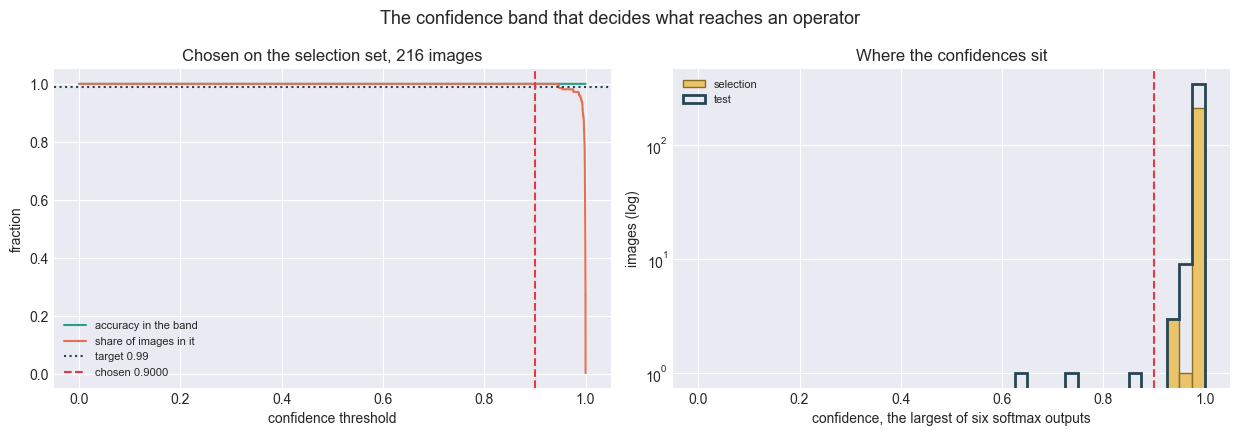

In [12]:
window = curve[(curve['n'] > 0) & (curve['accuracy'] >= TARGET_BAND_ACCURACY)]
flat_from, flat_to = float(window['threshold'].min()), float(window['threshold'].max())
print(f'the target is met for every threshold from {flat_from:.4f} to {flat_to:.4f}, '
      f'a span of {flat_to - flat_from:.4f}')
print(f'coverage across that span runs {window["coverage"].min():.1%} to {window["coverage"].max():.1%}')
print()
gaps = np.diff(np.sort(selection_confidence))
print(f'selection confidences: {(selection_confidence > 0.99).mean():.1%} above 0.99, '
      f'{(selection_confidence < 0.5).mean():.1%} below 0.5')
print(f'largest empty gap between two neighbouring confidences: {gaps.max():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
plotted = curve[curve['n'] > 0]
axes[0].plot(plotted['threshold'], plotted['accuracy'], color='#2a9d8f', label='accuracy in the band')
axes[0].plot(plotted['threshold'], plotted['coverage'], color='#e76f51', label='share of images in it')
axes[0].axhline(TARGET_BAND_ACCURACY, color='#264653', linestyle=':', label=f'target {TARGET_BAND_ACCURACY}')
axes[0].axvline(CONFIDENCE_THRESHOLD, color='#e63946', linestyle='--',
                label=f'chosen {CONFIDENCE_THRESHOLD:.4f}')
axes[0].set_xlabel('confidence threshold')
axes[0].set_ylabel('fraction')
axes[0].set_title('Chosen on the selection set, 216 images')
axes[0].legend(fontsize=8, loc='lower left')

axes[1].hist(selection_confidence, bins=40, range=(0, 1), color='#e9c46a',
             edgecolor='#8a6d1f', label='selection')
axes[1].hist(test_confidence, bins=40, range=(0, 1), histtype='step', linewidth=2,
             color='#264653', label='test')
axes[1].axvline(CONFIDENCE_THRESHOLD, color='#e63946', linestyle='--')
axes[1].set_yscale('log')
axes[1].set_xlabel('confidence, the largest of six softmax outputs')
axes[1].set_ylabel('images (log)')
axes[1].set_title('Where the confidences sit')
axes[1].legend(fontsize=8)
fig.suptitle('The confidence band that decides what reaches an operator', fontsize=13)
fig.tight_layout()
save_figure(fig, 'neu_operating_point', subfolder=ASSETS)
plt.show()

## 9. The test folder, scored once

The threshold above is now applied unchanged to the 360 images the dataset ships
as `validation/` and this module holds out as its test set.

In [13]:
test_coverage, test_band_accuracy, test_accepted = band(
    test_confidence, test_truth, test_prediction, CONFIDENCE_THRESHOLD)
test_accuracy = accuracy_score(test_truth, test_prediction)
test_macro_f1 = f1_score(test_truth, test_prediction, average='macro')

print(f'on the test folder, {len(test_truth)} images:')
print(f'  accuracy over everything      {test_accuracy:.4f}')
print(f'  macro F1                      {test_macro_f1:.4f}')
print(f'  errors                        {int((test_prediction != test_truth).sum())}')
print()
print(f'  confident band                {test_accepted} images ({test_coverage:.1%}), '
      f'accuracy {test_band_accuracy:.4f}')
print(f'  sent to a person              {len(test_truth) - test_accepted} images, '
      f'of which {int((test_prediction != test_truth)[test_confidence < CONFIDENCE_THRESHOLD].sum())} '
      f'would have been classified wrongly')
print()
print(f'the band accuracy asked for on selection was {TARGET_BAND_ACCURACY} and the '
      f'test folder returned {test_band_accuracy:.4f}')
print()
print(classification_report(test_truth, test_prediction, target_names=CLASSES, digits=4))

on the test folder, 360 images:
  accuracy over everything      1.0000
  macro F1                      1.0000
  errors                        0

  confident band                357 images (99.2%), accuracy 1.0000
  sent to a person              3 images, of which 0 would have been classified wrongly

the band accuracy asked for on selection was 0.99 and the test folder returned 1.0000

                 precision    recall  f1-score   support

        crazing     1.0000    1.0000    1.0000        60
      inclusion     1.0000    1.0000    1.0000        60
        patches     1.0000    1.0000    1.0000        60
 pitted_surface     1.0000    1.0000    1.0000        60
rolled-in_scale     1.0000    1.0000    1.0000        60
      scratches     1.0000    1.0000    1.0000        60

       accuracy                         1.0000       360
      macro avg     1.0000    1.0000    1.0000       360
   weighted avg     1.0000    1.0000    1.0000       360



The confusion matrix, and the per-class scores drawn beside it.

  ✓ Saved → assets\cv\neu_model_confusion.png


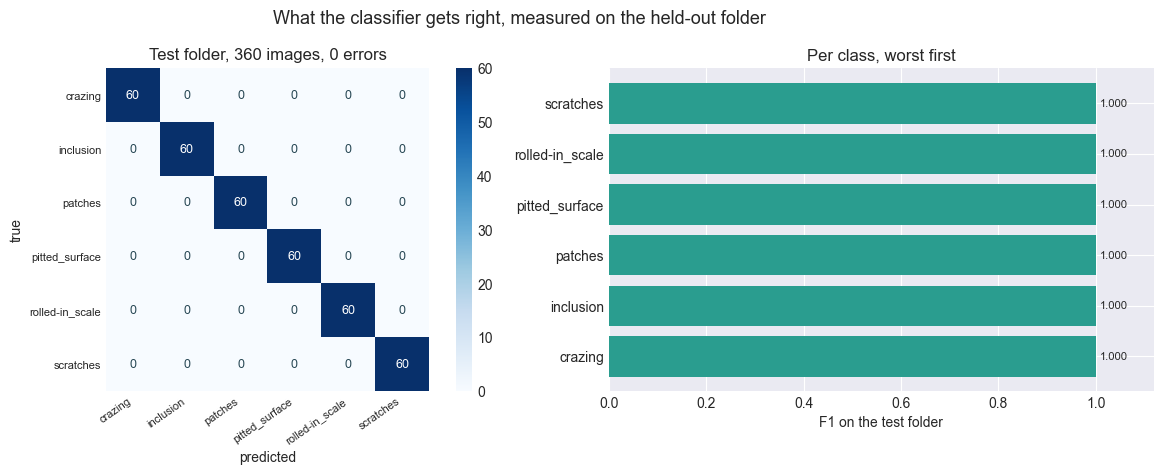

In [14]:
matrix = confusion_matrix(test_truth, test_prediction)
per_class_f1 = f1_score(test_truth, test_prediction, average=None)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
image = axes[0].imshow(matrix, cmap='Blues')
axes[0].set_xticks(range(len(CLASSES))); axes[0].set_yticks(range(len(CLASSES)))
axes[0].set_xticklabels(CLASSES, rotation=35, ha='right', fontsize=8)
axes[0].set_yticklabels(CLASSES, fontsize=8)
axes[0].set_xlabel('predicted'); axes[0].set_ylabel('true')
axes[0].grid(False)
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        axes[0].text(j, i, matrix[i, j], ha='center', va='center', fontsize=9,
                     color='white' if matrix[i, j] > matrix.max() / 2 else '#264653')
axes[0].set_title(f'Test folder, {len(test_truth)} images, '
                  f'{int((test_prediction != test_truth).sum())} errors')
fig.colorbar(image, ax=axes[0], fraction=0.046)

order = np.argsort(per_class_f1)
bars = axes[1].barh([CLASSES[i] for i in order], per_class_f1[order], color='#2a9d8f')
axes[1].bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
axes[1].set_xlim(0, 1.12)
axes[1].set_xlabel('F1 on the test folder')
axes[1].set_title('Per class, worst first')
fig.suptitle('What the classifier gets right, measured on the held-out folder', fontsize=13)
fig.tight_layout()
save_figure(fig, 'neu_model_confusion', subfolder=ASSETS)
plt.show()

## 10. Are the errors the images notebook 01 flagged

6.8 per cent of this dataset carries a second defect class the folder label
discards, and a single-label classifier cannot be right about both. If those
images are where the errors are, part of the error rate is the label's rather than
the model's. This cell asks directly.

In [15]:
wrong = test_prediction != test_truth
is_mixed = np.array(test_mixed)

table = pd.DataFrame({
    'images': [int(is_mixed.sum()), int((~is_mixed).sum())],
    'errors': [int(wrong[is_mixed].sum()), int(wrong[~is_mixed].sum())],
}, index=['carries a second class', 'single class only'])
table['error rate'] = (table['errors'] / table['images']).round(4)
print(table.to_string())
print()

# For a mixed image that was called wrong, was the predicted class one of the
# classes actually present in its boxes?
in_boxes = 0
for position in np.flatnonzero(wrong & is_mixed):
    if CLASSES[test_prediction[position]] in box_classes.get(test_stems[position], set()):
        in_boxes += 1
print(f'mixed-class images called wrong: {int(wrong[is_mixed].sum())}')
print(f'of those, the predicted class IS present in the image\'s own boxes: {in_boxes}')
print()
if not wrong.any():
    print('There are no errors on this folder at all, so the ceiling measured in notebook 01')
    print('was never reached. The 23 mixed-class images are a limit on what a single-label')
    print('classifier could score, not one this run ran into: on all 23 the model named the')
    print('class the folder claims, which is one of the classes actually in the frame.')
elif in_boxes:
    print(f'{in_boxes} of the mixed-class errors named a defect that IS in the picture. The')
    print('folder label calls them wrong because it carries only one of the two classes')
    print('present, so that part of the error rate belongs to the label, not to the model.')
else:
    print('No error named a class that is present in the image, so the second label does')
    print('not explain them and they belong to the model.')

                        images  errors  error rate
carries a second class      23       0         0.0
single class only          337       0         0.0

mixed-class images called wrong: 0
of those, the predicted class IS present in the image's own boxes: 0

There are no errors on this folder at all, so the ceiling measured in notebook 01
was never reached. The 23 mixed-class images are a limit on what a single-label
classifier could score, not one this run ran into: on all 23 the model named the
class the folder claims, which is one of the classes actually in the frame.


## 11. The frozen-backbone ablation

The same head on the same data with every convolution frozen, so only the final
linear layer is fitted. It answers what the ImageNet features are worth here
before any of them are adapted to steel, and it is the arm that reproduced exactly
on casting.

In [16]:
t0 = time.time()
frozen_model, frozen_history, frozen_best = train(
    freeze_backbone=True, seed=SEED, label='frozen ')
frozen_probabilities, frozen_truth = scores_for(frozen_model, test_loader)
frozen_prediction = frozen_probabilities.argmax(1)
print()
print(f'best epoch {frozen_best}, {time.time() - t0:.0f}s')
print(f'{"arm":<26}{"test accuracy":>15}{"test macro F1":>15}{"errors":>9}')
print(f'{"fine-tuned, all layers":<26}{test_accuracy:>15.4f}{test_macro_f1:>15.4f}'
      f'{int((test_prediction != test_truth).sum()):>9}')
print(f'{"frozen backbone":<26}{accuracy_score(frozen_truth, frozen_prediction):>15.4f}'
      f'{f1_score(frozen_truth, frozen_prediction, average="macro"):>15.4f}'
      f'{int((frozen_prediction != frozen_truth).sum()):>9}')

  frozen epoch  1  loss 1.86729  train acc 0.1822  selection macro F1 0.21512    5.5s


  frozen epoch  2  loss 1.62529  train acc 0.3619  selection macro F1 0.53621    5.4s


  frozen epoch  3  loss 1.41452  train acc 0.5882  selection macro F1 0.63463    5.6s


  frozen epoch  4  loss 1.24812  train acc 0.7353  selection macro F1 0.78250    5.3s


  frozen epoch  5  loss 1.09918  train acc 0.8186  selection macro F1 0.85404    5.5s


...

  frozen epoch  9  loss 0.71695  train acc 0.9257  selection macro F1 0.92130    5.6s


  frozen epoch 10  loss 0.65356  train acc 0.9289  selection macro F1 0.94437    5.6s


  frozen epoch 11  loss 0.61889  train acc 0.9363  selection macro F1 0.94434    5.9s


  frozen epoch 12  loss 0.57321  train acc 0.9289  selection macro F1 0.95809    5.4s



best epoch 12, 69s
arm                         test accuracy  test macro F1   errors
fine-tuned, all layers             1.0000         1.0000        0
frozen backbone                    0.8639         0.8586       49


Both training curves, on one basis: the same fitting set, the same selection set,
the same metric.

  ✓ Saved → assets\cv\neu_model_training.png


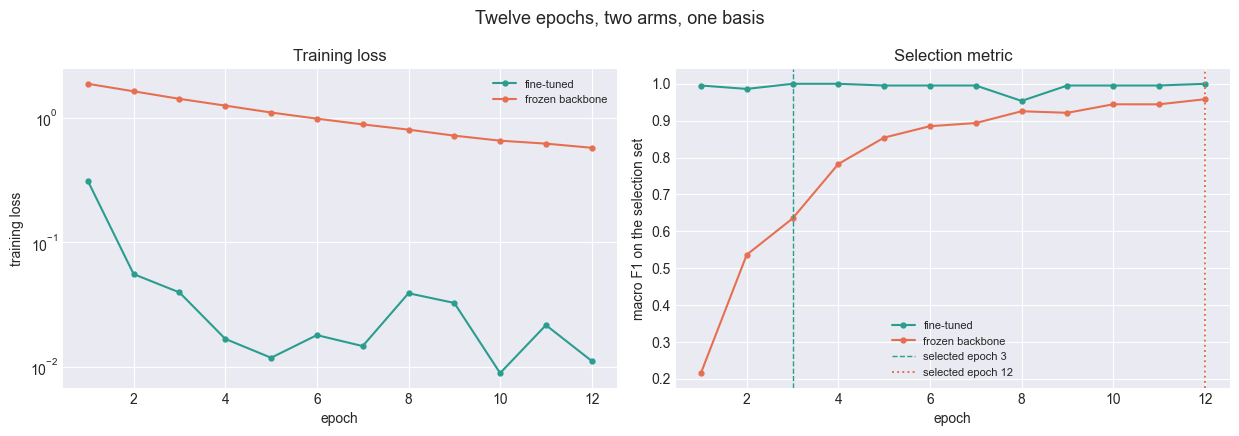

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
for name, rows, colour in (('fine-tuned', history, '#2a9d8f'),
                           ('frozen backbone', frozen_history, '#e76f51')):
    frame = pd.DataFrame(rows)
    axes[0].plot(frame['epoch'], frame['train_loss'], marker='o', markersize=3.5,
                 color=colour, label=name)
    axes[1].plot(frame['epoch'], frame['selection_macro_f1'], marker='o', markersize=3.5,
                 color=colour, label=name)
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('training loss')
axes[0].set_yscale('log'); axes[0].set_title('Training loss'); axes[0].legend(fontsize=8)
axes[1].axvline(best_epoch, color='#2a9d8f', linestyle='--', linewidth=1,
                label=f'selected epoch {best_epoch}')
axes[1].axvline(frozen_best, color='#e76f51', linestyle=':', linewidth=1.4,
                label=f'selected epoch {frozen_best}')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('macro F1 on the selection set')
axes[1].set_title('Selection metric'); axes[1].legend(fontsize=8)
fig.suptitle('Twelve epochs, two arms, one basis', fontsize=13)
fig.tight_layout()
save_figure(fig, 'neu_model_training', subfolder=ASSETS)
plt.show()

## 12. Does this reproduce: the same code, the same seed, a second time

Casting's fine-tuned arm never returned the same numbers twice while its frozen
arm was bit-identical every time, which located the non-determinism in the
convolution backward pass rather than in the code. That result makes this question
compulsory for every module here. This cell fits the fine-tuned arm again from the
same seed and compares everything the module reports.

In [18]:
t0 = time.time()
repeat_model, repeat_history, repeat_best = train(freeze_backbone=False, seed=SEED, label='repeat ')
repeat_selection, _ = scores_for(repeat_model, selection_loader)
repeat_test, _ = scores_for(repeat_model, test_loader)
repeat_prediction = repeat_test.argmax(1)
repeat_confidence = repeat_test.max(1)
print(f'\nsecond fine-tune done in {time.time() - t0:.0f}s')

  repeat epoch  1  loss 0.31131  train acc 0.9085  selection macro F1 0.98597    8.2s


  repeat epoch  2  loss 0.05455  train acc 0.9812  selection macro F1 0.99074    8.6s


  repeat epoch  3  loss 0.04037  train acc 0.9910  selection macro F1 1.00000    8.6s


  repeat epoch  4  loss 0.02066  train acc 0.9943  selection macro F1 1.00000    8.5s


  repeat epoch  5  loss 0.01184  train acc 0.9975  selection macro F1 1.00000    8.4s


...

  repeat epoch  9  loss 0.01798  train acc 0.9943  selection macro F1 0.99537    8.5s


  repeat epoch 10  loss 0.00899  train acc 0.9984  selection macro F1 0.99074    8.7s


  repeat epoch 11  loss 0.02110  train acc 0.9943  selection macro F1 0.99074    8.5s


  repeat epoch 12  loss 0.02472  train acc 0.9943  selection macro F1 1.00000    8.5s



second fine-tune done in 104s


In [19]:
# The same function run 1 used, so the two thresholds are on one basis. Comparing a
# declared threshold against a calibrated one would report a difference that is only
# a difference of rule.
repeat_threshold, repeat_calibrated, repeat_degenerate, _ = choose_threshold(
    repeat_selection.max(1), selection_truth, repeat_selection.argmax(1))
print(f'run 2: the calibration returned {repeat_calibrated:.4f} and '
      f'{"degenerated the same way" if repeat_degenerate else "held"}, '
      f'so its shipped threshold is {repeat_threshold:.4f}')

comparison = pd.DataFrame([
    {'value': 'best epoch', 'run 1': best_epoch, 'run 2': repeat_best},
    {'value': 'epoch 1 training loss', 'run 1': history[0]['train_loss'], 'run 2': repeat_history[0]['train_loss']},
    {'value': 'test accuracy', 'run 1': round(test_accuracy, 4),
     'run 2': round(accuracy_score(test_truth, repeat_prediction), 4)},
    {'value': 'test macro F1', 'run 1': round(test_macro_f1, 4),
     'run 2': round(f1_score(test_truth, repeat_prediction, average='macro'), 4)},
    {'value': 'test errors', 'run 1': int((test_prediction != test_truth).sum()),
     'run 2': int((repeat_prediction != test_truth).sum())},
    {'value': 'confidence threshold', 'run 1': round(CONFIDENCE_THRESHOLD, 4),
     'run 2': round(repeat_threshold, 4)},
    {'value': 'images sent to a person', 'run 1': int((test_confidence < CONFIDENCE_THRESHOLD).sum()),
     'run 2': int((repeat_confidence < repeat_threshold).sum())},
])
comparison['moved'] = comparison['run 1'] != comparison['run 2']
print(comparison.to_string(index=False))
print()
print(f'values compared: {len(comparison)}, of which moved: {int(comparison["moved"].sum())}')
print(f'the two runs disagree on {int((test_prediction != repeat_prediction).sum())} '
      f'of the {len(test_truth)} test images')

run 2: the calibration returned 0.0000 and degenerated the same way, so its shipped threshold is 0.9000
                  value   run 1   run 2  moved
             best epoch 3.00000 3.00000  False
  epoch 1 training loss 0.31096 0.31131   True
          test accuracy 1.00000 1.00000  False
          test macro F1 1.00000 1.00000  False
            test errors 0.00000 0.00000  False
   confidence threshold 0.90000 0.90000  False
images sent to a person 3.00000 3.00000  False

values compared: 7, of which moved: 1
the two runs disagree on 0 of the 360 test images


What matters operationally is the last two rows rather than the digits above them,
because the threshold and the count of images routed to a person are what the event
adapter turns into work for somebody. A training loss that moves in its fifth
decimal costs nothing; a band edge that moves changes who is asked to look at a
coil.

## 13. The priority bands the event adapter publishes

Every image in this dataset is a defect. There is no good-part class, so unlike
casting this module cannot decide whether a surface should pass; it can only say
which defect it is looking at and how sure it is. Two consequences fix the mapping.

The module publishes an event for every classified surface, the way CMAPSS
publishes one per engine, because there is no negative case to suppress. And the
priority is driven by confidence rather than by defect class, because ranking these
six defects by severity would require metallurgical judgement this project does not
have and inventing one would be worse than not having it. The defect type rides in
`risk_type` and in the evidence, where it belongs.

In [20]:
bands = [
    ('P2', 'below the confidence threshold: the model cannot name the defect, a person must',
     test_confidence < CONFIDENCE_THRESHOLD),
    ('P3', 'at or above it: the defect type is logged against the coil, reviewed daily',
     test_confidence >= CONFIDENCE_THRESHOLD),
]
print(f'the band edge is confidence {CONFIDENCE_THRESHOLD:.4f}, {threshold_basis}')
print()
print(f'{"priority":<10}{"images":>8}{"share":>9}{"wrong":>8}   meaning')
for priority, meaning, mask in bands:
    print(f'{priority:<10}{int(mask.sum()):>8}{mask.mean():>9.1%}'
          f'{int(wrong[mask].sum()):>8}   {meaning}')
print()
print('No P1: nothing here is safety-relevant without a severity ranking this module')
print('does not have. No P4: every image in this dataset is a defect, so there is no')
print('informational-only case. Both absences are recorded in the model card.')

the band edge is confidence 0.9000, declared, not calibrated: the selection set could not calibrate one because the model classified all of it correctly

priority    images    share   wrong   meaning
P2               3     0.8%       0   below the confidence threshold: the model cannot name the defect, a person must
P3             357    99.2%       0   at or above it: the defect type is logged against the coil, reviewed daily

No P1: nothing here is safety-relevant without a severity ranking this module
does not have. No P4: every image in this dataset is a defect, so there is no
informational-only case. Both absences are recorded in the model card.


## 14. Write the artifacts

Three files: the weights, the metrics file every downstream document cites, and
the prediction table the event adapter reads. Nothing here is overwritten, because
nothing exists yet.

In [21]:
PROC_DIR.mkdir(parents=True, exist_ok=True)
weights_path = MODEL_DIR / f'{MODEL_VERSION}.pt'
meta_path = MODEL_DIR / 'neu_cv_meta.json'
predictions_path = PROC_DIR / 'test_neu_predictions.npz'

torch.save(model.state_dict(), weights_path)

meta = {
    'dataset': 'NEU-DET surface defect database, hot-rolled steel strip, six defect classes',
    'architecture': 'resnet18, ImageNet weights, whole network fine-tuned',
    'task': 'six-class classification',
    'image_size': IMAGE_SIZE,
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
    'best_epoch': best_epoch,
    'learning_rate': LEARNING_RATE,
    'seed': SEED,
    'classes': {name: index for index, name in enumerate(CLASSES)},
    'split_note': ('the dataset ships train/ and validation/ and no test folder. The train '
                   'folder is cut 85/15 stratified for fitting and selection; the shipped '
                   'validation/ folder is held out and scored once as the test set.'),
    'fitting_images': len(fit_index),
    'selection_images': len(selection_index),
    'test_images': len(test_folder),
    'test_folder_source': 'the folder the dataset ships as validation/',
    'augmentation': ('horizontal and vertical flip, rotation up to '
                     f'{ROTATION_DEGREES} degrees; a quarter turn is excluded because it '
                     'inverts the texture direction the classes separate on'),
    'history': history,
    'benchmark_difficulty': {
        'note': ('measured before training on the same held-out folder, so the fine-tuned '
                 'result can be read against it rather than against chance'),
        'one_nearest_neighbour_on_imagenet_features': round(float(nn_accuracy), 4),
        'two_feature_pixel_baseline': round(float(pixel_accuracy), 4),
        'chance': round(1 / len(CLASSES), 4),
        'max_cosine_similarity_test_to_fitting': round(float(nearest_similarity.max()), 4),
        'median_cosine_similarity_test_to_fitting': round(float(np.median(nearest_similarity)), 4),
        'median_cosine_similarity_test_to_test': round(float(np.median(control)), 4),
    },
    'operating_point': {
        'rule': ('the lowest confidence at which the accepted predictions on the selection '
                 f'set are right at least {TARGET_BAND_ACCURACY:.0%} of the time'),
        'rule_degenerated': bool(degenerate),
        'basis': threshold_basis,
        'threshold_the_rule_returned': round(float(CALIBRATED_THRESHOLD), 4),
        'confidence_threshold': round(CONFIDENCE_THRESHOLD, 4),
        'selection_coverage': round(float(coverage), 4),
        'selection_band_accuracy': round(float(accuracy), 4),
        'test_coverage': round(float(test_coverage), 4),
        'test_band_accuracy': round(float(test_band_accuracy), 4),
        'test_images_sent_to_a_person': int((test_confidence < CONFIDENCE_THRESHOLD).sum()),
    },
    'test_performance': {
        'measured_on': 'the folder the dataset ships as validation/, 360 images, scored once',
        'accuracy': round(float(test_accuracy), 4),
        'macro_f1': round(float(test_macro_f1), 4),
        'errors': int((test_prediction != test_truth).sum()),
        'per_class_f1': {name: round(float(v), 4) for name, v in zip(CLASSES, per_class_f1)},
        'confusion_matrix': matrix.tolist(),
    },
    'label_ceiling': {
        'mixed_class_images_in_test': int(is_mixed.sum()),
        'errors_on_them': int(wrong[is_mixed].sum()),
        'errors_on_single_class_images': int(wrong[~is_mixed].sum()),
        'predicted_class_present_in_boxes': in_boxes,
    },
    'ablation_frozen_backbone': {
        'best_epoch': frozen_best,
        'history': frozen_history,
        'test_accuracy': round(float(accuracy_score(frozen_truth, frozen_prediction)), 4),
        'test_macro_f1': round(float(f1_score(frozen_truth, frozen_prediction, average='macro')), 4),
        'test_errors': int((frozen_prediction != frozen_truth).sum()),
    },
    'reproduction': {
        'note': 'the fine-tuned arm refitted from the same seed in the same session',
        'values_compared': len(comparison),
        'values_moved': int(comparison['moved'].sum()),
        'test_images_predicted_differently': int((test_prediction != repeat_prediction).sum()),
        'run_2_confidence_threshold': round(float(repeat_threshold), 4),
        'run_2_test_accuracy': round(float(accuracy_score(test_truth, repeat_prediction)), 4),
    },
}
meta_path.write_text(json.dumps(meta, indent=2), encoding='utf-8')

np.savez(predictions_path,
         paths=np.array([Path(p).resolve().relative_to(REPO_ROOT).as_posix()
                         for p, _ in test_folder.samples]),
         probabilities=test_probabilities,
         predicted_label=test_prediction,
         confidence=test_confidence,
         true_label=test_truth,
         classes=np.array(CLASSES))

for path in (weights_path, meta_path, predictions_path):
    print(f'{path.stat().st_size / 1e6:>8.2f} MB  {path.as_posix()}')
stored = np.load(predictions_path, allow_pickle=False)['paths'][0]
print(f'first stored image path: {stored}')
print(f'it resolves from the repository root: {(REPO_ROOT / str(stored)).is_file()}')

   44.80 MB  ../../../models/checkpoints/neu/neu_resnet18_v1.pt
    0.01 MB  ../../../models/checkpoints/neu/neu_cv_meta.json
    0.12 MB  ../../../data/04_neu/processed/test_neu_predictions.npz
first stored image path: data/04_neu/raw/validation/images/crazing/crazing_241.jpg
it resolves from the repository root: True


## 15. Log the run

Into the same SQLite tracking store as the other three modules, under the
experiment name the README already advertised before this module existed.

In [22]:
import mlflow

mlflow.set_tracking_uri(get_mlflow_uri())
mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name=MODEL_VERSION):
    mlflow.set_tags({'dataset': 'neu_det', 'task': 'multiclass_classification',
                     'framework': 'pytorch', 'architecture': 'resnet18',
                     'num_classes': str(len(CLASSES)), 'department': 'Rolling Mill',
                     'business_domain': 'visual_inspection'})
    mlflow.log_params({'image_size': IMAGE_SIZE, 'batch_size': BATCH_SIZE,
                       'epochs': EPOCHS, 'learning_rate': LEARNING_RATE, 'seed': SEED,
                       'best_epoch': best_epoch,
                       'validation_fraction': VALIDATION_FRACTION,
                       'target_band_accuracy': TARGET_BAND_ACCURACY})
    mlflow.log_metrics({'test_accuracy': float(test_accuracy),
                        'test_macro_f1': float(test_macro_f1),
                        'test_errors': int((test_prediction != test_truth).sum()),
                        'confidence_threshold': float(CONFIDENCE_THRESHOLD),
                        'test_band_accuracy': float(test_band_accuracy),
                        'test_coverage': float(test_coverage),
                        'frozen_test_macro_f1': float(f1_score(frozen_truth, frozen_prediction, average='macro'))})
    for row in history:
        mlflow.log_metrics({'train_loss': row['train_loss'],
                            'selection_macro_f1': row['selection_macro_f1']}, step=row['epoch'])
    mlflow.log_artifact(str(meta_path))
    run = mlflow.active_run()
    print(f'logged run {run.info.run_id} to experiment {EXPERIMENT_NAME}')

logged run 488599c4ecad4dc09dc1c0fb5dc3295e to experiment arkon-cv-neu


## 16. Results

In [23]:
print(f'1. Six-class classifier over {len(fit_index):,} fitting images. On the held-out folder, '
      f'{len(test_truth)} images the dataset ships as validation/ and this module scored once: '
      f'accuracy {test_accuracy:.4f}, macro F1 {test_macro_f1:.4f}, '
      f'{int(wrong.sum())} error{"" if wrong.sum() == 1 else "s"}.')
print(f'2. That number is about the benchmark before it is about the model. A 1-nearest-'
      f'neighbour classifier on untrained ImageNet features already reaches {nn_accuracy:.4f} '
      f'on the same folder, and a two-number pixel baseline reaches {pixel_accuracy:.4f} '
      f'against {1 / len(CLASSES):.3f} chance.')
print(f'3. The held-out folder is genuinely unseen: no test image is closer than '
      f'{nearest_similarity.max():.4f} cosine to anything fitted on, and it sits as close to '
      f'the rest of the test folder ({np.median(control):.4f}) as to the fitting set '
      f'({np.median(nearest_similarity):.4f}).')
frozen_accuracy = accuracy_score(frozen_truth, frozen_prediction)
print(f'4. Freezing the backbone costs '
      f'{test_macro_f1 - f1_score(frozen_truth, frozen_prediction, average="macro"):.4f} macro F1 '
      f'and {int((frozen_prediction != frozen_truth).sum())} errors, so the '
      f'{(test_accuracy - frozen_accuracy) * 100:.1f} accuracy points between '
      f'{frozen_accuracy:.4f} and {test_accuracy:.4f} are what fine-tuning buys.')
print(f'5. The confidence rule could not be calibrated: the model classified all '
      f'{len(selection_truth)} selection images correctly, so every threshold met the target. '
      f'The shipped band edge {CONFIDENCE_THRESHOLD:.2f} is declared, not measured, and the '
      f'model card says so.')
print(f'6. At that edge {int((test_confidence < CONFIDENCE_THRESHOLD).sum())} of {len(test_truth)} '
      f'test images go to a person as P2 and the rest are logged as P3.')
flipped = int((test_prediction != repeat_prediction).sum())
edge_moved = round(CONFIDENCE_THRESHOLD, 4) != round(repeat_threshold, 4)
print(f'7. Refitting from the same seed moved {int(comparison["moved"].sum())} of '
      f'{len(comparison)} reported values and changed {flipped} of {len(test_truth)} '
      f'predictions, so the same GPU non-determinism casting found is present here too.')
print(f'8. What differs is whether it reaches the operating point. The band edge '
      f'{"moved" if edge_moved else "did not move"} '
      f'({CONFIDENCE_THRESHOLD:.4f} against {repeat_threshold:.4f}), where the casting module spans '
      f'0.0436 to 0.2203 across four runs of one seed. Casting searches for its threshold on '
      f'a cost curve with no well-determined minimum; this module declares its band edge, so '
      f'there is nothing for the noise to amplify.')

1. Six-class classifier over 1,224 fitting images. On the held-out folder, 360 images the dataset ships as validation/ and this module scored once: accuracy 1.0000, macro F1 1.0000, 0 errors.
2. That number is about the benchmark before it is about the model. A 1-nearest-neighbour classifier on untrained ImageNet features already reaches 0.9750 on the same folder, and a two-number pixel baseline reaches 0.4861 against 0.167 chance.
3. The held-out folder is genuinely unseen: no test image is closer than 0.9823 cosine to anything fitted on, and it sits as close to the rest of the test folder (0.9428) as to the fitting set (0.9378).
4. Freezing the backbone costs 0.1414 macro F1 and 49 errors, so the 13.6 accuracy points between 0.8639 and 1.0000 are what fine-tuning buys.
5. The confidence rule could not be calibrated: the model classified all 216 selection images correctly, so every threshold met the target. The shipped band edge 0.90 is declared, not measured, and the model card says 